In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
import jax
import jax.numpy as jnp

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns  

import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [11]:
# Define paths (Relative to 'analysis' folder)
data_dir = os.path.join("..", "Data")
file_name = "liesel_output_camera_40000_samples.pkl"
pkl_path = os.path.join(data_dir, file_name)

print(f"Looking for data at: {os.path.abspath(pkl_path)}")

# Load the pickle file and extract contents
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        saved_data = pickle.load(f)
    
    print("File loaded successfully.")
    
    # Extract contents
    results = saved_data["results"]
    samples = saved_data["samples"]
    runtime_seconds = saved_data["runtime_seconds"]
    runtime_formatted = saved_data["runtime_formatted"]
    
    # Check shape
    print(f"Script runtime: {runtime_formatted}")
    print(f"Time per sample (seconds): {runtime_seconds / (samples['beta_i'].shape[0] * samples['beta_i'].shape[1]):.6f}")
    print(f"Beta shape (Chains, Draws, Units, Params):      {samples['beta_i'].shape}")
    print(f"Mu shape (Chains, Draws, Params):               {samples['mu'].shape}")
    print(f"Sigma shape (Chains, Draws, Params, Params):    {samples['sigma_inv_chol_latent'].shape}")
    
else:
    print("Error: Pickle file not found. Make sure you ran the training script first.")

Looking for data at: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\liesel_output_camera_40000_samples.pkl
File loaded successfully.
Script runtime: 2:37:33
Time per sample (seconds): 0.236349
Beta shape (Chains, Draws, Units, Params):      (4, 10000, 332, 10)
Mu shape (Chains, Draws, Params):               (4, 10000, 10)
Sigma shape (Chains, Draws, Params, Params):    (4, 10000, 55)


In [9]:
# Get the latent samples
# Shape: (chains, draws, 15)
latent_samples = results.get_posterior_samples()["sigma_inv_chol_latent"]
n_chains, n_draws, n_latent = latent_samples.shape

# Setup the bijector (must match the one in the model)
bijector = tfb.FillScaleTriL()

# Function to turn 1D vector -> 5x5 Matrix -> Covariance Matrix
def latent_to_sigma(latent_vec):
    # Map 15-dim vector to 5x5 Lower Triangular Matrix (L)
    L = bijector.forward(latent_vec)

    # Compute Precision (Omega = L @ L.T)
    # Invert to get Covariance (Sigma = inv(Omega))
    # This is equivalent to inv(L.T) @ inv(L) which is more stable
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# Vectorize across chains and draws
v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))
sigma_samples = v_latent_to_sigma(latent_samples)

# Compute posterior mean of Sigma
sigma_posterior_mean = jnp.mean(sigma_samples, axis=(0, 1))

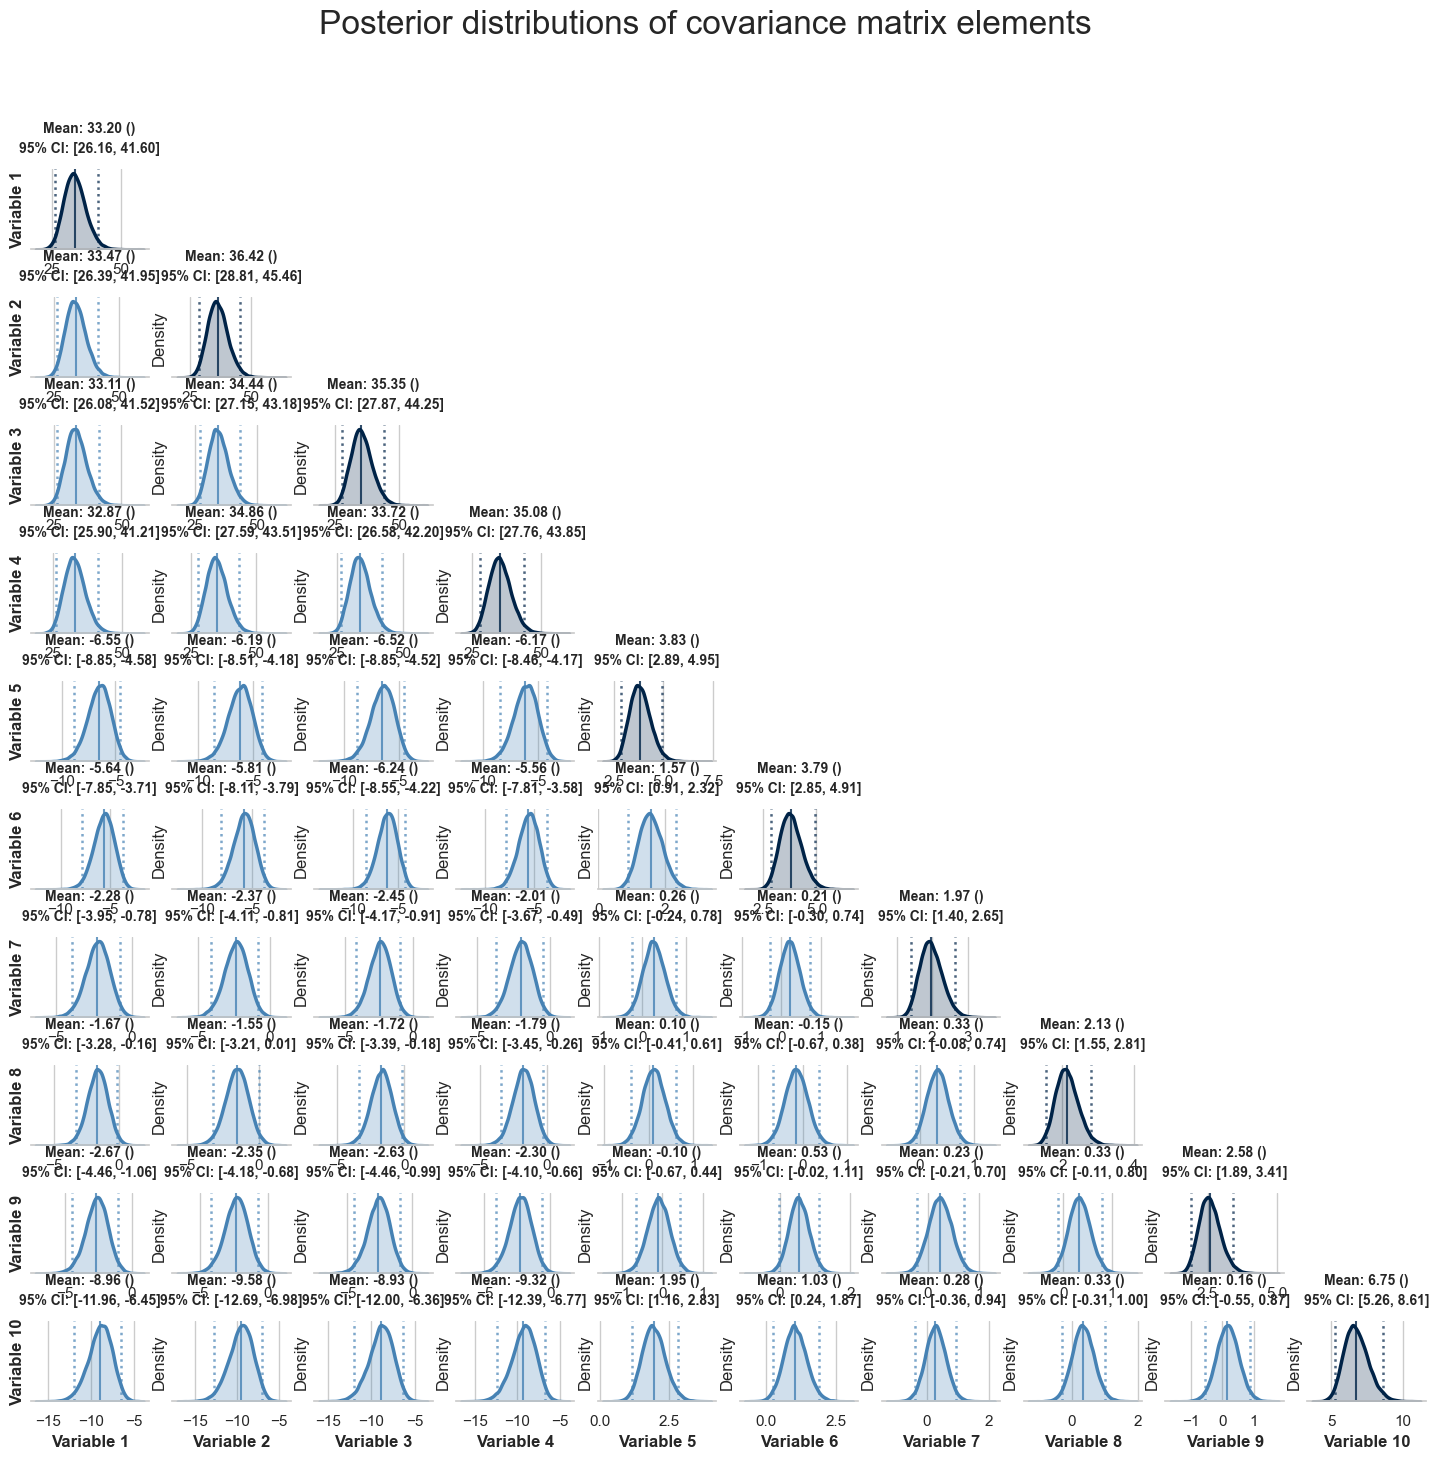

In [6]:
def plot_final_covariance_complete(samples, true_matrix=None):
    n_dim = samples.shape[-1]
    # Extra large figure for maximum readability
    _, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    # Color Palette
    diag_color =     "#002347"
    off_diag_color = "#4682B4"
    true_val_color = "#D62728"

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # 1. Lower Triangular Logic
            if j > i:
                ax.axis('off')
                continue
            
            data = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            # 2. Stats Calculation
            post_mean = np.mean(data)
            ci_low, ci_high = np.percentile(data, [2.5, 97.5])
            
            # 3. Plot KDE
            sns.kdeplot(data, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            # 4. Reference Lines
            # Mean line (Solid)
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            
            # 95% CI Lines (Dotted)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            # True Value (Dashed Red)
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
            
            # 5. Textual Labels (Title with CI stated)
            title_str = (
                f"Mean: {post_mean:.2f} "
                f"({'True: ' + str(round(true_val, 2)) if true_matrix is not None else ''})\n"
                f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            )
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            # 6. Aesthetic Polish
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            # Label only the edges to keep it clean
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    plt.suptitle("Posterior distributions of covariance matrix elements", 
                 fontsize=24, y=0.98, fontweight='light')
    
    # Spacing to prevent cramping and accommodate multi-line titles
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# Run the plot
plot_final_covariance_complete(sigma_samples)

In [7]:
# 1. Flatten Chains and Draws
# ---------------------------
# We combine chains (4) and draws (2000) into a single dimension -> (8000, Units, Params)
beta_raw = samples['beta_i']
n_chains, n_draws, n_units, n_params = beta_raw.shape
beta_flat = beta_raw.reshape(n_chains * n_draws, n_units, n_params)

print(f"Reshaped for analysis: {beta_flat.shape}")

# 2. Select First Customer (Index 0)
# ----------------------------------
unit_idx = 0
customer_betas = beta_flat[:, unit_idx, :] # Shape: (8000, 10)

# 3. Create DataFrame
# -------------------
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]
df_cust = pd.DataFrame(customer_betas, columns=param_names)

# Melt for Seaborn
df_melted = df_cust.melt(var_name="Parameter", value_name="Utility")

print(f"Data ready for Customer #{unit_idx + 1}")

Reshaped for analysis: (40000, 332, 10)
Data ready for Customer #1


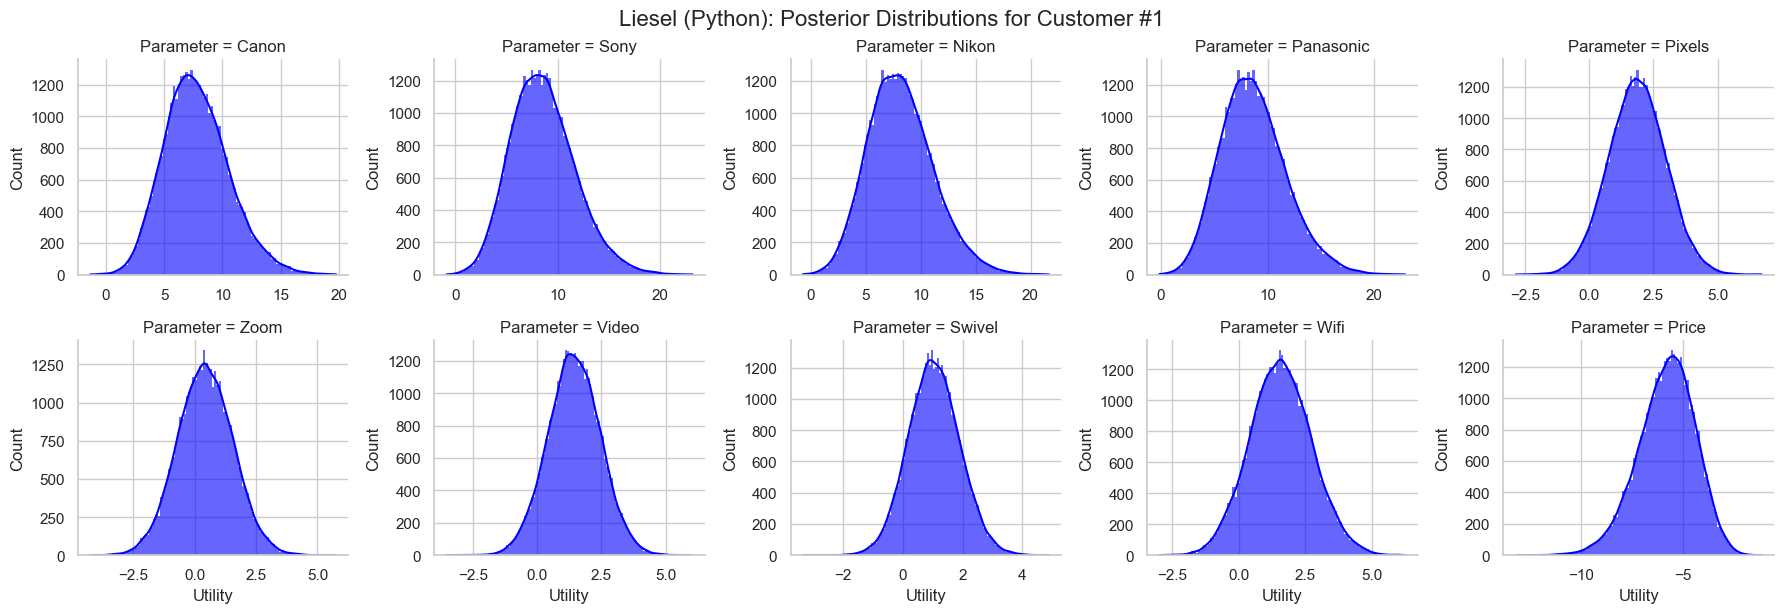

In [13]:
# Plot Distributions (Facet Grid)
g = sns.FacetGrid(
    df_melted, 
    col="Parameter", 
    col_wrap=5,      # 5 plots per row
    sharex=False,    # Let x-axis scales vary per parameter
    sharey=False,    # Let y-axis scales vary (density height)
    height=3, 
    aspect=1.2
)

# Add Histograms with KDE (Kernel Density Estimate)
# Using orange to distinguish from R plots (usually blue/teal)
g.map(sns.histplot, "Utility", kde=True, color="blue", alpha=0.6, linewidth=0)

# Titles
g.fig.suptitle(f"Liesel (Python): Posterior Distributions for Customer #{unit_idx+1}", y=1.02, fontsize=16)

plt.show()